In [1]:
import numpy as np
import pandas as pd
import os
import mat73
from sklearn import svm
from sklearn import metrics
import scipy.io
from scipy import stats
import matplotlib.pyplot as plt
from scipy import stats, linalg
import warnings
import joblib

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.base")

from sklearn.exceptions import ConvergenceWarning
def conv_r2z(r):
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))
def conv_z2r(z):
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

# load the arousal SVR

In [2]:
# Load the model (optional if you just saved it)
clf = joblib.load('./svr_model.pkl')
print('Model loaded successfully!')

Model loaded successfully!


In [3]:
# load the arousal network
arousal_network = scipy.io.loadmat('./arousal_network.mat')['arousal_network']

# load the feature ids
nR = 122 # the Yeo 114 atlas for cortical regions + Brainnectome atlas for subcortical
# for the Brainnectome atlas, follow this order: left amygdala, hippocampus, basal ganglia, and thalamus, then right amygdala, hippocampus, basal ganglia, and thalamus
feat_id = []
ii = -1
for i in range(nR-1):
    for j in range(i+1,nR):
        ii = ii + 1
        if arousal_network[i,j] != 0: # this includes both positive and negative features
            feat_id.append(ii)
feat_id = np.array(feat_id)
print('Arousal network loaded. It has',len(feat_id),'FC features')

Arousal network loaded. It has 237 FC features


# load your own testing data -- e.g., Merlin

In [4]:
# load brain -- BetweenViewings Dataset
# The format of the brain data should be nsubj*nFC*nTR

# 1. Using scipy instead of mat73 since NSG output is standard .mat
brain_BetweenViewings = scipy.io.loadmat(r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\04_data\NSG results\BetweenViewings\output\BetweenViewings_NSG_Job\sliding-dynFeat-BetweenViewings.mat')['dynFeat']

# 2. Z-scoring per feature
brain_BetweenViewings_zscored = scipy.stats.zscore(brain_BetweenViewings, 2, nan_policy='omit') 

# 3. Applying the 122 parcel mask

dynFC_test = brain_BetweenViewings_zscored[:, feat_id, :] 

print('  model learn: brain entire feature shape ' + str(dynFC_test.shape))

  model learn: brain entire feature shape (29, 237, 731)


In [5]:
# check for any missing TRs
nanidx = []
for subj in range(dynFC_test.shape[0]):
    for ft in range(dynFC_test.shape[1]):
        if np.any(np.isnan(dynFC_test[subj,ft,:])):
            nanidx.append(ft)

nanidx = np.unique(nanidx)
print('NaN = '+str(nanidx))

if len(nanidx)>0:
    dynFC_test = np.delete(dynFC_test,nanidx,1)

print('Number of nans in selected FC: '+str(len(nanidx)))
print('DynFC_test Shape: '+str(dynFC_test.shape))

NaN = []
Number of nans in selected FC: 0
DynFC_test Shape: (29, 237, 731)


# apply the model to your own fMRI data, to predict the moment-to-moment arousal fluctuations of each participant

In [6]:
test_nsubj = 29 
predicted_arousal = []

for test_sub in range(test_nsubj):
    test_feat = dynFC_test[test_sub, :, :]
    rmtr_test = []
    
    for tm in range(test_feat.shape[1]):
        if np.all(np.isnan(test_feat[:, tm])):
            rmtr_test.append(tm)
            
    rmtr_test = np.asarray(rmtr_test)
    if len(rmtr_test) > 0:
        test_feat = np.delete(test_feat, rmtr_test, 1)
        #test behavior doesnt exist for BetweenViewings, so we do not need to use that command
    
    predicted = clf.predict(test_feat.T)
    predicted_arousal.append(predicted)

predicted_arousal = np.array(predicted_arousal)

# Save the predictions 
save_path = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\BetweenViewings\Predicted_Arousal_BetweenViewings.npy'
np.save(save_path, predicted_arousal)
print(f"Success! Predictions saved to: {save_path}")

Success! Predictions saved to: C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\BetweenViewings\Predicted_Arousal_BetweenViewings.npy


Loaded Predictions Shape: (29, 731)

--- Loading IntenseEmotion TSV Data ---
Loaded IntenseEmotion Shape: (808,)

--- Correlation Results ---
Cohort Average Pearson r: 0.4061 (p-value: 4.6400e-26)
Mean Subject-Level Pearson r: 0.2123


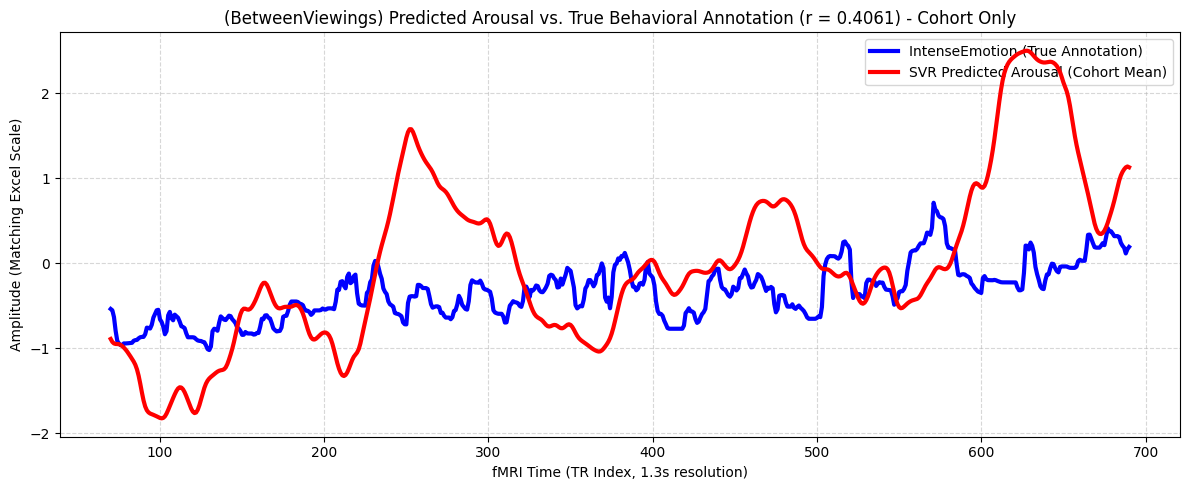

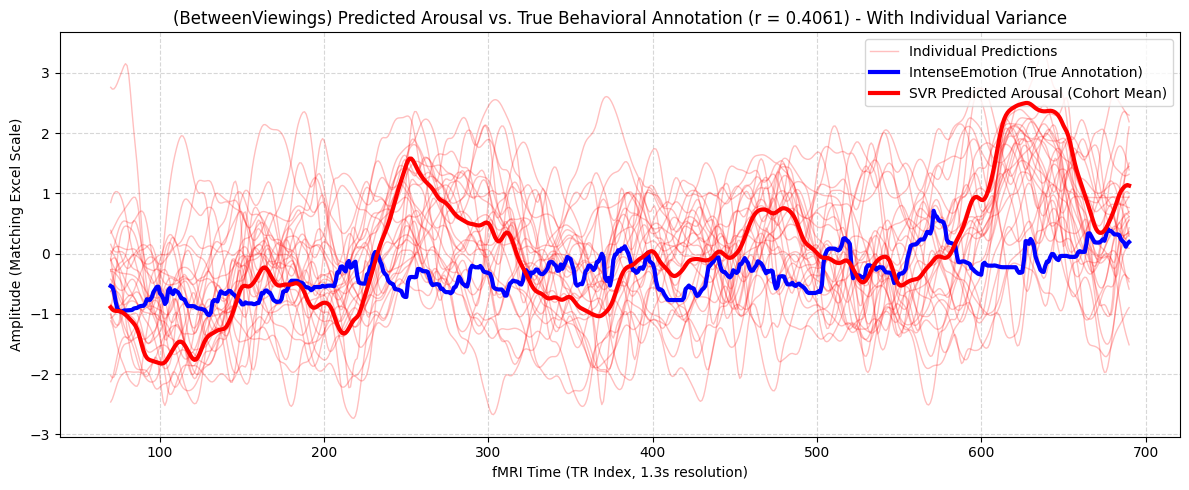

In [2]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD PREDICTIONS
# ==========================================
pred_path = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\BetweenViewings\Predicted_Arousal_BetweenViewings.npy'
predicted_arousal = np.load(pred_path)
print(f"Loaded Predictions Shape: {predicted_arousal.shape}")

# ==========================================
# 2. LOAD & PARSE BEHAVIORAL ANNOTATIONS
# ==========================================
MOVIE_NAME = 'BetweenViewings'
print("\n--- Loading IntenseEmotion TSV Data ---")
emotion_path = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\data\annotation_files\Annot_BetweenViewings_stim.tsv'

json_columns = [
   "Standards",
        "PleasantSelf",
        "SocialNorms",
        "PleasantOther",
        "GoalsOther",
        "Controlled",
        "Predictable",
        "Suddenly",
        "Agent",
        "Urgency",
        "Lips",
        "Tears",
        "Eyebrows",
        "Smile",
        "Frown",
        "Stop",
        "Undo",
        "Repeat",
        "Oppose",
        "Attention",
        "Tackle",
        "Command",
        "Support",
        "Move",
        "Care",
        "Bad",
        "Good",
        "Calm",
        "Strong",
        "IntenseEmotion",
        "Alert",
        "AtEase",
        "Muscle",
        "Heartrate",
        "Throat",
        "Stomach",
        "Warm",
        "Anger",
        "Guilt",
        "WarmHeartedness",
        "Disgust",
        "Happiness",
        "Fear",
        "Regard",
        "Anxiety",
        "Satisfaction",
        "Pride",
        "Surprise",
        "Love",
        "Sad"
]

emotion_df = pd.read_csv(emotion_path, sep='\t', header=None, names=json_columns)

intense_emotion_1hz = emotion_df['IntenseEmotion'].values
movie_duration_sec = len(intense_emotion_1hz)
print(f"Loaded IntenseEmotion Shape: {intense_emotion_1hz.shape}")

# ==========================================
# 3. GLOBAL TEMPORAL ALIGNMENT (SECONDS)
# ==========================================
tr_duration = 1.3
total_scan_trs = 776
window_size = 45

all_tr_times = np.arange(total_scan_trs) * tr_duration

pred_window_centers_tr = np.arange(predicted_arousal.shape[1]) + (window_size / 2.0)
pred_times_sec = pred_window_centers_tr * tr_duration

annot_start_sec = 90.0
annot_times_sec = np.arange(movie_duration_sec) + annot_start_sec

# ==========================================
# 4. ISOLATE AND RESAMPLE THE MOVIE BLOCK
# ==========================================
movie_tr_mask = (all_tr_times >= annot_start_sec) & (all_tr_times <= (annot_start_sec + movie_duration_sec))
movie_tr_times = all_tr_times[movie_tr_mask]

annot_interpolator = interp1d(annot_times_sec, intense_emotion_1hz, kind='linear', bounds_error=False, fill_value='extrapolate')
emotion_at_trs = annot_interpolator(movie_tr_times)

mean_predicted_arousal = np.mean(predicted_arousal, axis=0)
pred_interpolator = interp1d(pred_times_sec, mean_predicted_arousal, kind='linear', bounds_error=False, fill_value='extrapolate')
pred_at_trs = pred_interpolator(movie_tr_times)

# ==========================================
# 5. STATISTICAL VALIDATION
# ==========================================
print("\n--- Correlation Results ---")
r_group, p_group = pearsonr(emotion_at_trs, pred_at_trs)
print(f"Cohort Average Pearson r: {r_group:.4f} (p-value: {p_group:.4e})")

subject_rs = []
subject_preds_at_trs = []  

for subj in range(predicted_arousal.shape[0]):
    subj_pred_interpolator = interp1d(pred_times_sec, predicted_arousal[subj, :], kind='linear', bounds_error=False, fill_value='extrapolate')
    subj_pred_at_trs = subj_pred_interpolator(movie_tr_times)
    
    r_val, _ = pearsonr(emotion_at_trs, subj_pred_at_trs)
    subject_rs.append(r_val)
    subject_preds_at_trs.append(subj_pred_at_trs)  

print(f"Mean Subject-Level Pearson r: {np.mean(subject_rs):.4f}")

# ==========================================
# 6. VISUAL PLOTTING
# ==========================================
movie_tr_indices = movie_tr_times / tr_duration

# Prepare the properly scaled cohort average 
norm_pred = (pred_at_trs - np.mean(pred_at_trs)) / (np.std(pred_at_trs) + 1e-8)

# ---------------------------------------------------------
# GRAPH 1: Clean Cohort Average (No Individual Lines)
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

plt.plot(movie_tr_indices, emotion_at_trs, label='IntenseEmotion (True Annotation)', color='blue', linewidth=3, zorder=5)
plt.plot(movie_tr_indices, norm_pred, label='SVR Predicted Arousal (Cohort Mean)', color='red', linewidth=3, zorder=6)

plt.title(f'({MOVIE_NAME}) Predicted Arousal vs. True Behavioral Annotation (r = {r_group:.4f}) - Cohort Only')
plt.xlabel('fMRI Time (TR Index, 1.3s resolution)')
plt.ylabel('Amplitude (Matching Excel Scale)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRAPH 2: Cohort Average + Individual Subject Variance
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Plot Individual Background Lines First
for idx, subj_pred in enumerate(subject_preds_at_trs):
    norm_subj_pred = (subj_pred - np.mean(subj_pred)) / (np.std(subj_pred) + 1e-8)
    label_str = 'Individual Predictions' if idx == 0 else ""
    plt.plot(movie_tr_indices, norm_subj_pred, color='red', alpha=0.25, linewidth=1, label=label_str)

# Plot the Bold Foreground Lines strictly over the background (using zorder)
plt.plot(movie_tr_indices, emotion_at_trs, label='IntenseEmotion (True Annotation)', color='blue', linewidth=3, zorder=5)
plt.plot(movie_tr_indices, norm_pred, label='SVR Predicted Arousal (Cohort Mean)', color='red', linewidth=3, zorder=6)

plt.title(f'({MOVIE_NAME}) Predicted Arousal vs. True Behavioral Annotation (r = {r_group:.4f}) - With Individual Variance')
plt.xlabel('fMRI Time (TR Index, 1.3s resolution)')
plt.ylabel('Amplitude (Matching Excel Scale)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
import os
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

def main():
    # ==========================================
    # 1. CONFIGURATION & FILE PATHS
    # ==========================================
    MOVIE_NAME = 'BetweenViewings'
    
    # Parameters to process (mapped exactly to the JSON keys)
    # Note: 'Breathing' is not in the standard JSON, the script will gracefully skip it.
    target_params = ['Predictable', 'Alert', 'Attention', 'Heartrate', 'Breathing', 'IntenseEmotion']
    
    base_dir = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS'
    pred_path = os.path.join(base_dir, '05_extracted_features', MOVIE_NAME, f'Predicted_Arousal_{MOVIE_NAME}.npy')
    
    data_dir = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\data\annotation_files'
    emotion_path = os.path.join(data_dir, f'Annot_{MOVIE_NAME}_stim.tsv')
    
    output_base_dir = os.path.join(base_dir, '05_extracted_features', MOVIE_NAME, 'Behavioral_Comparisons')

    # ==========================================
    # 2. LOAD PREDICTIONS
    # ==========================================
    print(f"--- Loading SVR Predictions for {MOVIE_NAME} ---")
    try:
        predicted_arousal = np.load(pred_path)
    except FileNotFoundError:
        print(f"[!] Error: Could not find predictions at {pred_path}")
        return
        
    print(f"Loaded Predictions Shape: {predicted_arousal.shape}")

    # ==========================================
    # 3. LOAD & PARSE BEHAVIORAL ANNOTATIONS
    # ==========================================
    print(f"\n--- Loading Behavioral TSV Data ---")
    json_columns = [
        "Standards", "PleasantSelf", "SocialNorms", "PleasantOther", "GoalsOther",
        "Controlled", "Predictable", "Suddenly", "Agent", "Urgency", "Lips",
        "Tears", "Eyebrows", "Smile", "Frown", "Stop", "Undo", "Repeat",
        "Oppose", "Attention", "Tackle", "Command", "Support", "Move", "Care",
        "Bad", "Good", "Calm", "Strong", "IntenseEmotion", "Alert", "AtEase",
        "Muscle", "Heartrate", "Throat", "Stomach", "Warm", "Anger", "Guilt",
        "WarmHeartedness", "Disgust", "Happiness", "Fear", "Regard", "Anxiety",
        "Satisfaction", "Pride", "Surprise", "Love", "Sad"
    ]

    try:
        emotion_df = pd.read_csv(emotion_path, sep='\t', header=None, names=json_columns)
    except FileNotFoundError:
        print(f"[!] Error: Could not find TSV at {emotion_path}")
        return

    # ==========================================
    # 4. BATCH PROCESS EACH PARAMETER
    # ==========================================
    for param in target_params:
        print(f"\n==========================================")
        print(f"Processing Feature: {param}")
        
        if param not in emotion_df.columns:
            print(f"[WARNING] '{param}' is not present in the behavioral data. Skipping...")
            continue
            
        # Create output directory for the specific parameter
        param_out_dir = os.path.join(output_base_dir, param)
        os.makedirs(param_out_dir, exist_ok=True)

        param_1hz = emotion_df[param].values
        movie_duration_sec = len(param_1hz)
        print(f"Loaded {param} Shape: {param_1hz.shape}")

        # --- GLOBAL TEMPORAL ALIGNMENT (SECONDS) ---
        tr_duration = 1.3
        total_scan_trs = 776
        window_size = 45

        all_tr_times = np.arange(total_scan_trs) * tr_duration

        pred_window_centers_tr = np.arange(predicted_arousal.shape[1]) + (window_size / 2.0)
        pred_times_sec = pred_window_centers_tr * tr_duration

        annot_start_sec = 90.0
        annot_times_sec = np.arange(movie_duration_sec) + annot_start_sec

        # --- ISOLATE AND RESAMPLE THE MOVIE BLOCK ---
        movie_tr_mask = (all_tr_times >= annot_start_sec) & (all_tr_times <= (annot_start_sec + movie_duration_sec))
        movie_tr_times = all_tr_times[movie_tr_mask]

        annot_interpolator = interp1d(annot_times_sec, param_1hz, kind='linear', bounds_error=False, fill_value='extrapolate')
        param_at_trs = annot_interpolator(movie_tr_times)

        mean_predicted_arousal = np.mean(predicted_arousal, axis=0)
        pred_interpolator = interp1d(pred_times_sec, mean_predicted_arousal, kind='linear', bounds_error=False, fill_value='extrapolate')
        pred_at_trs = pred_interpolator(movie_tr_times)

        # --- STATISTICAL VALIDATION ---
        r_group, p_group = pearsonr(param_at_trs, pred_at_trs)
        
        subject_rs = []
        subject_preds_at_trs = []  

        for subj in range(predicted_arousal.shape[0]):
            subj_pred_interpolator = interp1d(pred_times_sec, predicted_arousal[subj, :], kind='linear', bounds_error=False, fill_value='extrapolate')
            subj_pred_at_trs = subj_pred_interpolator(movie_tr_times)
            
            r_val, _ = pearsonr(param_at_trs, subj_pred_at_trs)
            subject_rs.append(r_val)
            subject_preds_at_trs.append(subj_pred_at_trs)  
            
        mean_subj_r = np.mean(subject_rs)
        
        print(f"Cohort Average Pearson r: {r_group:.4f} (p: {p_group:.4e})")

        # Save stats to text file
        stats_path = os.path.join(param_out_dir, f"{param}_Correlation_Stats.txt")
        with open(stats_path, 'w') as f:
            f.write(f"Correlation Statistics: SVR Predicted Arousal vs {param}\n")
            f.write("-" * 50 + "\n")
            f.write(f"Cohort-Level Pearson r : {r_group:.4f}\n")
            f.write(f"Cohort-Level p-value   : {p_group:.4e}\n")
            f.write(f"Mean Subject-Level r   : {mean_subj_r:.4f}\n")

        # --- VISUAL PLOTTING ---
        movie_tr_indices = movie_tr_times / tr_duration
        norm_pred = (pred_at_trs - np.mean(pred_at_trs)) / (np.std(pred_at_trs) + 1e-8)

        # Graph 1: Clean Cohort Average
        plt.figure(figsize=(12, 5))
        plt.plot(movie_tr_indices, param_at_trs, label=f'{param} (True Annotation)', color='blue', linewidth=3, zorder=5)
        plt.plot(movie_tr_indices, norm_pred, label='SVR Predicted Arousal (Cohort Mean)', color='red', linewidth=3, zorder=6)
        plt.title(f'({MOVIE_NAME}) Predicted Arousal vs. {param} (r = {r_group:.4f}) - Cohort Only')
        plt.xlabel('fMRI Time (TR Index, 1.3s resolution)')
        plt.ylabel('Amplitude')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig(os.path.join(param_out_dir, f"{param}_Overlay_Cohort.png"), dpi=300)
        plt.close()

        # Graph 2: Cohort Average + Individual Subject Variance
        plt.figure(figsize=(12, 5))
        for idx, subj_pred in enumerate(subject_preds_at_trs):
            norm_subj_pred = (subj_pred - np.mean(subj_pred)) / (np.std(subj_pred) + 1e-8)
            label_str = 'Individual Predictions' if idx == 0 else ""
            plt.plot(movie_tr_indices, norm_subj_pred, color='red', alpha=0.25, linewidth=1, label=label_str)

        plt.plot(movie_tr_indices, param_at_trs, label=f'{param} (True Annotation)', color='blue', linewidth=3, zorder=5)
        plt.plot(movie_tr_indices, norm_pred, label='SVR Predicted Arousal (Cohort Mean)', color='red', linewidth=3, zorder=6)
        plt.title(f'({MOVIE_NAME}) Predicted Arousal vs. {param} (r = {r_group:.4f}) - With Individual Variance')
        plt.xlabel('fMRI Time (TR Index, 1.3s resolution)')
        plt.ylabel('Amplitude')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig(os.path.join(param_out_dir, f"{param}_Overlay_Individuals.png"), dpi=300)
        plt.close()
        
        print(f"-> Successfully saved plots and stats to: {param_out_dir}")

    print("\n==========================================")
    print("Batch processing complete.")

if __name__ == "__main__":
    main()

--- Loading SVR Predictions for BetweenViewings ---
Loaded Predictions Shape: (29, 731)

--- Loading Behavioral TSV Data ---

Processing Feature: Predictable
Loaded Predictable Shape: (808,)
Cohort Average Pearson r: -0.0616 (p: 1.2522e-01)
-> Successfully saved plots and stats to: C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\BetweenViewings\Behavioral_Comparisons\Predictable

Processing Feature: Alert
Loaded Alert Shape: (808,)
Cohort Average Pearson r: -0.3295 (p: 3.4342e-17)
-> Successfully saved plots and stats to: C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\BetweenViewings\Behavioral_Comparisons\Alert

Processing Feature: Attention
Loaded Attention Shape: (808,)
Cohort Average Pearson r: 0.2720 (p: 5.3615e-12)
-> Successfully saved plots and stats to: C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\BetweenViewings\Behavioral_Comparison

In [4]:
import os
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import pearsonr

def main():
    # ==========================================
    # 1. CONFIGURATION & FILE PATHS
    # ==========================================
    MOVIE_NAME = 'BetweenViewings'
    
    # Parameters to process
    target_params = ['Predictable', 'Alert', 'Attention', 'Heartrate', 'Breathing', 'IntenseEmotion']
    
    base_dir = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS'
    pred_path = os.path.join(base_dir, '05_extracted_features', MOVIE_NAME, f'Predicted_Arousal_{MOVIE_NAME}.npy')
    
    data_dir = r'C:\Users\ragha\Desktop\Honors Work Arousal Analysis\data\annotation_files'
    emotion_path = os.path.join(data_dir, f'Annot_{MOVIE_NAME}_stim.tsv')
    
    # Define the Behavioral Comparisons folder
    output_base_dir = os.path.join(base_dir, '05_extracted_features', MOVIE_NAME, 'Behavioral_Comparisons')
    os.makedirs(output_base_dir, exist_ok=True)
    
    # Set the Excel file to save directly inside that Behavioral Comparisons folder
    output_excel_path = os.path.join(output_base_dir, f'{MOVIE_NAME}_Individual_Correlations.xlsx')

    # ==========================================
    # 2. LOAD PREDICTIONS
    # ==========================================
    print(f"--- Loading SVR Predictions for {MOVIE_NAME} ---")
    try:
        predicted_arousal = np.load(pred_path)
    except FileNotFoundError:
        print(f"[!] Error: Could not find predictions at {pred_path}")
        return
        
    num_subjects = predicted_arousal.shape[0]
    print(f"Loaded Predictions Shape: {predicted_arousal.shape} ({num_subjects} Subjects)")

    # Initialize a dictionary to build our DataFrame later
    subject_labels = [f"Subject_{i+1:02d}" for i in range(num_subjects)]
    excel_data = {'Subject': subject_labels}

    # ==========================================
    # 3. LOAD BEHAVIORAL ANNOTATIONS
    # ==========================================
    print(f"\n--- Loading Behavioral TSV Data ---")
    json_columns = [
        "Standards", "PleasantSelf", "SocialNorms", "PleasantOther", "GoalsOther",
        "Controlled", "Predictable", "Suddenly", "Agent", "Urgency", "Lips",
        "Tears", "Eyebrows", "Smile", "Frown", "Stop", "Undo", "Repeat",
        "Oppose", "Attention", "Tackle", "Command", "Support", "Move", "Care",
        "Bad", "Good", "Calm", "Strong", "IntenseEmotion", "Alert", "AtEase",
        "Muscle", "Heartrate", "Throat", "Stomach", "Warm", "Anger", "Guilt",
        "WarmHeartedness", "Disgust", "Happiness", "Fear", "Regard", "Anxiety",
        "Satisfaction", "Pride", "Surprise", "Love", "Sad"
    ]

    try:
        emotion_df = pd.read_csv(emotion_path, sep='\t', header=None, names=json_columns)
    except FileNotFoundError:
        print(f"[!] Error: Could not find TSV at {emotion_path}")
        return

    # ==========================================
    # 4. LOOP AND CALCULATE INDIVIDUAL CORRELATIONS
    # ==========================================
    for param in target_params:
        print(f"Calculating correlations for: {param}")
        
        # If the parameter is missing, fill BOTH the r-value and p-value columns with NaNs
        if param not in emotion_df.columns:
            print(f"  -> [WARNING] '{param}' missing. Filling columns with empty values.")
            excel_data[param] = [np.nan] * num_subjects
            excel_data[f"{param}_pvalue"] = [np.nan] * num_subjects
            continue

        param_1hz = emotion_df[param].values
        movie_duration_sec = len(param_1hz)

        # --- TEMPORAL ALIGNMENT ---
        tr_duration = 1.3
        total_scan_trs = 776
        window_size = 45

        all_tr_times = np.arange(total_scan_trs) * tr_duration
        pred_window_centers_tr = np.arange(predicted_arousal.shape[1]) + (window_size / 2.0)
        pred_times_sec = pred_window_centers_tr * tr_duration
        
        annot_start_sec = 90.0
        annot_times_sec = np.arange(movie_duration_sec) + annot_start_sec

        # --- MASKING & RESAMPLING ---
        movie_tr_mask = (all_tr_times >= annot_start_sec) & (all_tr_times <= (annot_start_sec + movie_duration_sec))
        movie_tr_times = all_tr_times[movie_tr_mask]

        annot_interpolator = interp1d(annot_times_sec, param_1hz, kind='linear', bounds_error=False, fill_value='extrapolate')
        param_at_trs = annot_interpolator(movie_tr_times)

        # --- SUBJECT-LEVEL STATISTICS ---
        param_corrs = []
        param_pvals = []
        for subj in range(num_subjects):
            subj_pred_interpolator = interp1d(pred_times_sec, predicted_arousal[subj, :], kind='linear', bounds_error=False, fill_value='extrapolate')
            subj_pred_at_trs = subj_pred_interpolator(movie_tr_times)
            
            # Capture both the r-value and the p-value
            r_val, p_val = pearsonr(param_at_trs, subj_pred_at_trs)
            param_corrs.append(r_val)
            param_pvals.append(p_val)
            
        # Store both lists in the dictionary side-by-side
        excel_data[param] = param_corrs
        excel_data[f"{param}_pvalue"] = param_pvals

    # ==========================================
    # 5. BUILD DATAFRAME AND EXPORT TO EXCEL
    # ==========================================
    print("\n--- Constructing Excel Spreadsheet ---")
    df_results = pd.DataFrame(excel_data)
    
    # Initialize the three new summary rows
    mean_row = {'Subject': 'MEAN_COHORT (p < 0.05 only)'}
    max_pval_row = {'Subject': 'MAX_P_VALUE (p < 0.05)'}
    exclusion_row = {'Subject': 'EXCLUDED_SUBJECTS (p >= 0.05)'}
    
    for param in target_params:
        if param in df_results.columns:
            pval_col = f"{param}_pvalue"
            
            # 1. Handle completely missing columns (e.g., Breathing)
            if df_results[param].isna().all():
                mean_row[param] = np.nan
                mean_row[pval_col] = np.nan
                max_pval_row[param] = np.nan
                max_pval_row[pval_col] = np.nan
                exclusion_row[param] = "N/A - Missing Data"
                exclusion_row[pval_col] = ""
                continue
            
            # 2. Create Boolean masks for significance 
            valid_mask = df_results[pval_col] < 0.05
            invalid_mask = df_results[pval_col] >= 0.05
            
            # 3. Calculate filtered mean (only for valid subjects)
            mean_row[param] = df_results.loc[valid_mask, param].mean()
            mean_row[pval_col] = df_results.loc[valid_mask, pval_col].mean()
            
            # 4. Extract the MAXIMUM p-value that is STILL SIGNIFICANT (< 0.05)
            if valid_mask.any():
                # Get the index of the highest p-value strictly within the valid_mask subset
                max_sig_p_idx = df_results.loc[valid_mask, pval_col].idxmax()
                
                # Pull both the p-value and its corresponding r-value using that index
                max_pval_row[pval_col] = df_results.loc[max_sig_p_idx, pval_col]
                max_pval_row[param] = df_results.loc[max_sig_p_idx, param]
            else:
                # Fallback if literally zero subjects reached significance
                max_pval_row[pval_col] = "None"
                max_pval_row[param] = "None"
            
            # 5. Record the names of subjects who failed the p-value threshold
            excluded_subs = df_results.loc[invalid_mask, 'Subject'].tolist()
            exclusion_row[param] = ", ".join(excluded_subs) if excluded_subs else "None"
            exclusion_row[pval_col] = "" 
            
    # Append the mean row, max p-value row, and exclusion list row to the bottom of the DataFrame
    df_results = pd.concat([df_results, pd.DataFrame([mean_row, max_pval_row, exclusion_row])], ignore_index=True)
    
    # Export to .xlsx
    df_results.to_excel(output_excel_path, index=False, float_format="%.5f")
    print(f"-> Successfully saved Excel file to: {output_excel_path}")

if __name__ == "__main__":
    main()

--- Loading SVR Predictions for BetweenViewings ---
Loaded Predictions Shape: (29, 731) (29 Subjects)

--- Loading Behavioral TSV Data ---
Calculating correlations for: Predictable
Calculating correlations for: Alert
Calculating correlations for: Attention
Calculating correlations for: Heartrate
Calculating correlations for: Breathing
  -> [WARNING] 'Breathing' missing. Filling columns with empty values.
Calculating correlations for: IntenseEmotion

--- Constructing Excel Spreadsheet ---
-> Successfully saved Excel file to: C:\Users\ragha\Desktop\Honors Work Arousal Analysis\01_Aim_1_fMRI_to_ARS\05_extracted_features\BetweenViewings\Behavioral_Comparisons\BetweenViewings_Individual_Correlations.xlsx
